In [1]:
import os
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"
os.environ["VLLM_USE_FLASHINFER_SAMPLER"] = "0"

import matplotlib.pyplot as plt

from modules.dataset import PanoramaDataset
from modules.panorama import split_panorama
from modules.lvlm import QwenVLBackend
from modules.descriptions import DescriptionStore

{'panoid': '2ar5YEfUFbX8AFv6lTT51A', 'pano_lat': '56.21652264980573', 'pano_lon': '10.28951380687832', 'image_path': 'images/shard_000000.tar::2ar5YEfUFbX8AFv6lTT51A_360.jpg'}
Panorama size: (4096, 1024)


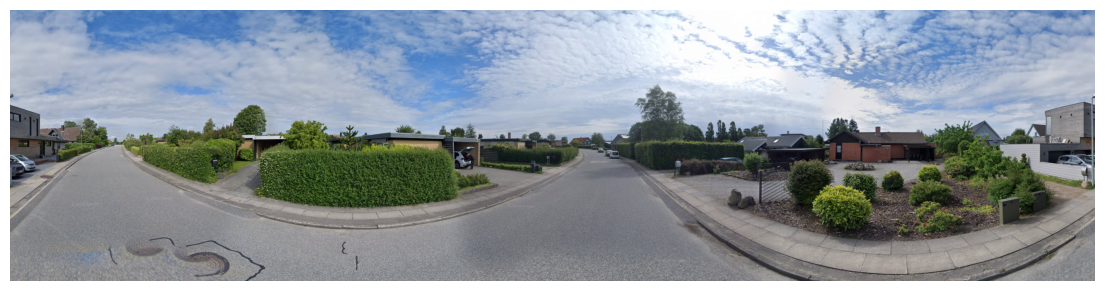

In [2]:
################################
# Load Panorama from dataset
################################

dataset = PanoramaDataset(
    dataset_root="test_dataset",
    shuffle=False,
    exclude_columns=[
        "pano_date",
        "query_lat",
        "query_lon",
        "snap_distance_m",
        "source",
        "source_value",
        "image_type",
        "yaw",
        "pitch",
        "fov",
    ],
)

panorama, metadata = next(iter(dataset))

print(metadata)
print("Panorama size:", panorama.size)

plt.figure(figsize=(14, 4))
plt.imshow(panorama)
plt.axis("off")
plt.show()

Number of subimages: 6
Index 0: 768x768
Index 1: 768x768
Index 2: 768x768
Index 3: 768x768
Index 4: 768x768
Index 5: 768x768


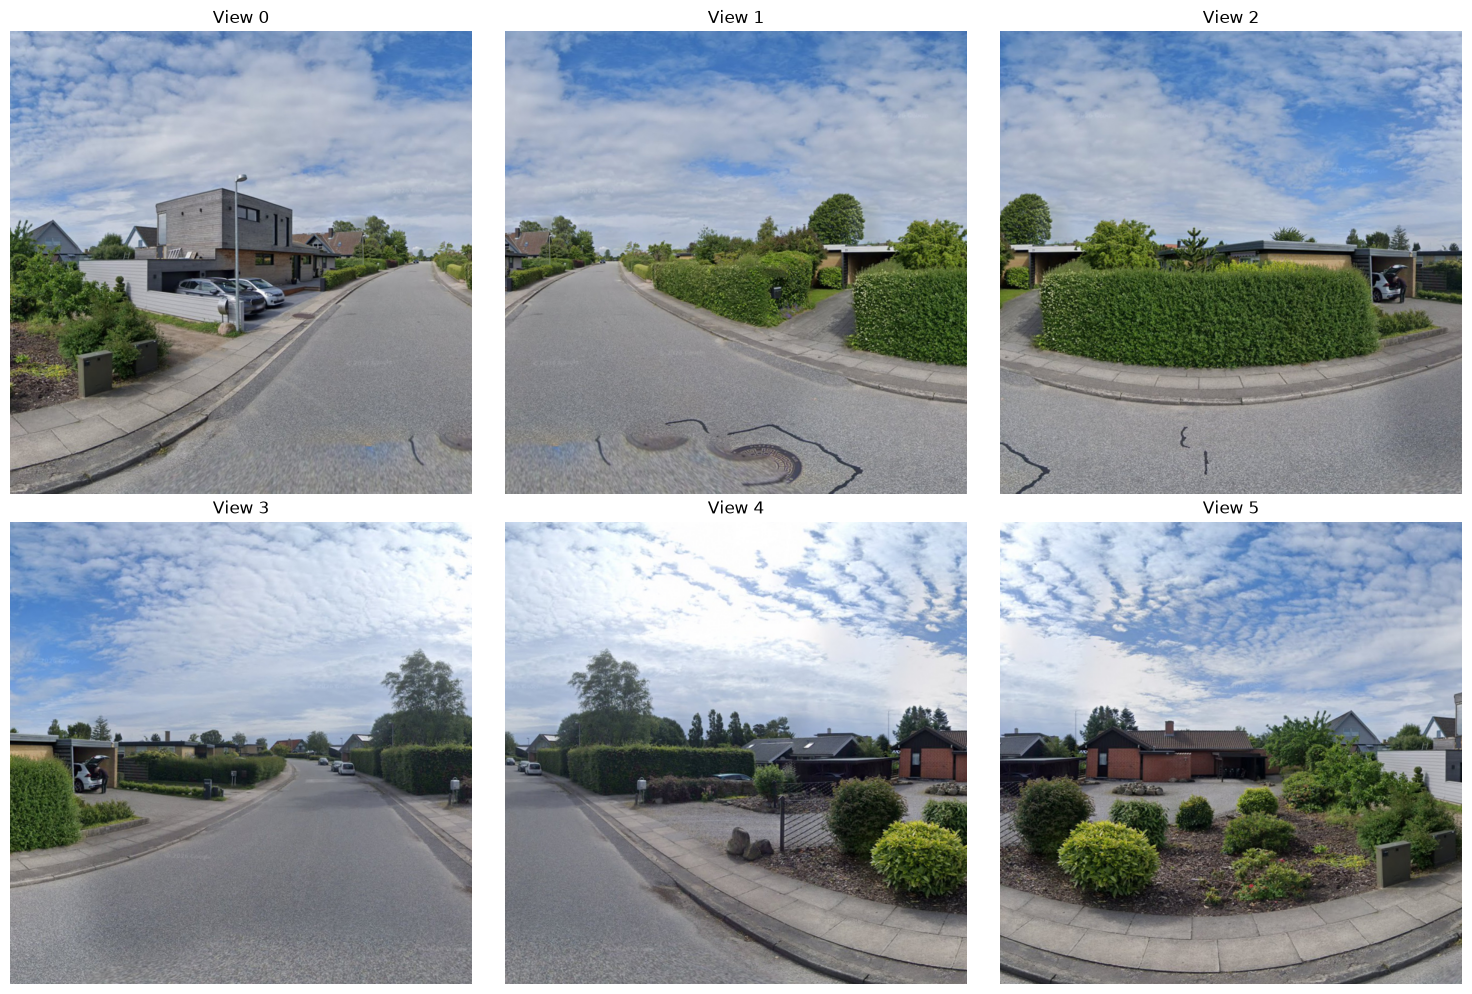

In [3]:
################################
# Split Panorama into 6 subimages
################################

subimages = split_panorama(panorama)

print("Number of subimages:", len(subimages))

for crop in subimages:
    print(
        f"Index {crop.subimage_index}: "
        f"{crop.image.width}x{crop.image.height}"
    )


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, crop in zip(axes.flat, subimages):
    ax.imshow(crop.image)
    ax.set_title(f"View {crop.subimage_index}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
backend = QwenVLBackend(
    model_name="cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.7,
    max_model_len=1024,
    dtype="auto",
    mm_processor_cache_gb=0,
    enforce_eager=False,
)

print("Backend initialized")

INFO 09-24 10:44:46 [api_utils.py:286] non-default args: {'tokenizer': 'cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', 'trust_remote_code': True, 'max_model_len': 1024, 'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 1, 'video': 0}, 'mm_processor_cache_gb': 0, 'model': 'cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit'}
WARNING 09-24 10:44:46 [arg_utils.py:1801] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-24 10:44:47 [model.py:684] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 09-24 10:44:47 [model.py:2021] Using max model len 1024
WARNING 09-24 10:44:47 [model.py:981] Model does not support mm_device_do_normalize, forcing mm_device_do_normalize = False.
INFO 09-24 10:44:49 [scheduler.py:277] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-24 10:44:49 [kernel.py:369] Final IR op priority after sett

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


INFO 09-24 10:44:56 [core.py:123] Initializing a V1 LLM engine (v0.29.0) with config: model='cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', speculative_config=None, tokenizer='cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=1024, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=compressed-tensors, quantization_config=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 09-24 10:45:00 [weight_utils.py:797] Prefetching checkpoint files: 10% (1/1)
INFO 09-24 10:45:00 [weight_utils.py:820] Prefetching checkpoint files into page cache finished in 0.59s
INFO 09-24 10:45:00 [default_loader.py:430] Loading weights took 1.16 seconds
INFO 09-24 10:45:01 [model_runner.py:404] Model loading took 4.52 GiB memory and 3.987726 seconds
INFO 09-24 10:45:01 [topk_topp_sampler.py:46] FlashInfer top-p/top-k sampling disabled via VLLM_USE_FLASHINFER_SAMPLER=0.
INFO 09-24 10:45:01 [utils.py:306] Using LBNHC KV cache layout.
INFO 09-24 10:45:02 [encoder_runner.py:131] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
INFO 09-24 10:45:34 [backends.py:1094] Using cache directory: /home/austen/.cache/vllm/torch_compile_cache/0a3dc9c67c/rank_0_0/backbone for vLLM's torch.compile
INFO 09-24 10:45:34 [backends.py:1155] Dynamo bytecode transform time: 10.87 s
INFO 09-24 10:45:54 [backends.py:393] Com

...

INFO 09-24 10:46:12 [model_runner.py:960] Graph capturing finished in 8 secs, took 0.41 GiB


INFO 09-24 10:46:12 [gpu_worker.py:625] Available KV cache memory: 0.92 GiB
INFO 09-24 10:46:12 [gpu_worker.py:640] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.7000 is equivalent to --gpu-memory-utilization=0.6602 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.7398. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
INFO 09-24 10:46:12 [kv_cache_utils.py:2032] GPU KV cache size: 6,656 tokens, Maximum concurrency for 1,024 tokens per request: 6.50x
INFO 09-24 10:46:12 [kernel_warmup.py:124] JIT kernel warmup starting.
INFO 09-24 10:46:12 [kernel_warmup.py:134] JIT kernel warmup finished in 0.00s.


Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:02<00:00, 16.47it/s]

INFO 09-24 10:46:23 [model_runner.py:960] Graph capturing finished in 10 secs, took 0.26 GiB
INFO 09-24 10:46:23 [gpu_worker.py:797] CUDA graph pool memory: 0.26 GiB (actual), 0.46 GiB (estimated), difference: 0.2 GiB (76.9%).
INFO 09-24 10:46:23 [gpu_worker.py:860] Free memory on device (11.52/11.63 GiB) on startup. Desired GPU memory utilization is (0.7, 8.14 GiB). Actual usage is 4.83 GiB for consumed memory (weights + non-torch), 2.39 GiB for peak activation, and 0.26 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=544616756` (0.51 GiB) to fit into requested memory, or `--kv-cache-memory=4173102592` (3.89 GiB) to fully utilize gpu memory. Current kv cache memory in use is 0.92 GiB.


INFO 09-24 10:46:31 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
INFO 09-24 10:46:31 [torch_utils.py:277] Reducing Torch threads from 12 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
INFO 09-24 10:46:31 [core.py:361] init engine (profile, create kv cache, warmup model) took 90.08 s (compilation: 35.97 s)
INFO 09-24 10:46:33 [hf.py:547] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.
INFO 09-24 10:46:42 [base.py:244] Multi-modal warmup completed in 8.691s
Backend initialized


In [5]:
crop = subimages[0]

response = backend.generate(
    image=crop.image,
    prompt="Describe this image.",
    max_tokens=128,
    temperature=0.0,
    top_p=0.95,
    repetition_penalty=1.0,
)

print("Model:", response.model_name)
print("Prompt:", response.prompt)
print()
print(response.text)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.66s/it, est. speed input: 355.71 toks/s, output: 77.17 toks/s]

Model: cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit
Prompt: Describe this image.

This is a daytime street-level photograph of a modern, single-family home in a suburban neighborhood, under a partly cloudy sky.

**Key Details:**

- **The House:** The central focus is a contemporary, two-story house with a gray, possibly wood-paneled or stone facade. It features a flat roof, large rectangular windows, and a prominent, low-slung garage or carport on the ground level. The architecture is clean and minimalist.

- **The Street & Environment:** The house is situated on a paved residential street with a curb and sidewalk. The road curves gently to the right, with a low hedge lining the right side


In [6]:
responses = backend.generate_batch(
    images=[crop.image for crop in subimages],
    prompt="Describe the visible environment in this image.",
    max_tokens=128,
    temperature=0.0,
)

for crop, response in zip(subimages, responses):
    print(f"\n--- View {crop.subimage_index} ---")
    print(response.text)

Rendering prompts:   0%|          | 0/6 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 6/6 [00:03<00:00,  1.99it/s, est. speed input: 1181.27 toks/s, output: 254.55 toks/s]


--- View 0 ---
This is a bright, sunny day in a quiet, modern residential neighborhood. The sky is a vibrant blue, filled with scattered, fluffy white clouds, suggesting pleasant weather.

The main focus is a contemporary, two-story house with a striking, minimalist design. It features a combination of materials: the upper level is clad in dark grey or black horizontal siding, while the lower level and the attached garage have a lighter, possibly white or light grey, horizontal siding. The house has a flat roof and a series of large, dark-framed windows, giving it a sleek, modern aesthetic. A prominent feature is the garage, which is integrated into

--- View 1 ---
This is a tranquil, sunlit suburban street scene on a partly cloudy day.

- **Sky and Weather**: The sky is a bright blue, filled with scattered, fluffy white clouds, suggesting a pleasant, mild day.
- **Road and Infrastructure**: A paved asphalt road curves gently to the left, with a manhole cover visible in the foreground

In [ ]:
panoid = metadata["panoid"]

db_path = "test_descriptions.sqlite"

with DescriptionStore(db_path) as store:
    for crop, response in zip(subimages, responses):
        store.add(
            panoid=panoid,
            subimage_index=crop.subimage_index,
            prompt_index=0,
            description=response.text,
        )

print(f"Stored descriptions in {db_path}")

In [ ]:
with DescriptionStore("test_descriptions.sqlite", read_only=True) as store:
    for crop in subimages:
        description = store.get(
            panoid=metadata["panoid"],
            subimage_index=crop.subimage_index,
            prompt_index=0,
        )

        print(f"\n--- View {crop.subimage_index} ---")
        print(description)